## Домашнее задание 21

In [228]:
#!pip install networkx

In [229]:
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

class Graph:
    def __init__(self, is_dirercted = True, colors = ['red', 'orange', 'blue', 'green',]):
        self.merge = {}
        self.is_dirercted = is_dirercted
        self.graph = nx.DiGraph() if is_dirercted else nx.Graph()
        self.colors = colors
        self.pos = None

    def add(self, v, merged_v): # добавляем в граф вершину v и смежные ей в листе merged_v
        self.merge[v] = merged_v
        self.graph.add_node(v)
        for v_m in merged_v:
            self.graph.add_node(v_m)
            self.graph.add_edge(v, v_m)
        self.pos = nx.spring_layout(self.graph)


    def _draw_graph(self, color_map): # num,
        #plt.figure(num)
        nx.draw_networkx(self.graph, arrows = self.is_dirercted, node_color=color_map, with_labels=True, pos=self.pos, node_size=1000, font_size=18, linewidths=3)
        plt.show()

    #
    # обход в ширину
    #
    def BFS(self, v_start):
        queue = deque()
        queue.append(v_start)
        seen = set([v_start])

        color_map = [self.colors[0] for _ in range(len(self.graph.nodes()))]
        color_map[v_start] = self.colors[1]
        self._draw_graph(color_map)

        while queue:
            v = queue.popleft()
            color_map[v] = self.colors[2]
            self._draw_graph(color_map)

            for m_v in self.merge[v]:
                if m_v not in seen:
                    queue.append(m_v)
                    seen.add(m_v)
                    color_map[m_v] = self.colors[1]
                    self._draw_graph(color_map)

            color_map[v] = self.colors[3]
            self._draw_graph(color_map)
        return


    #
    # обход в глубину
    #
    def DFS(self, v_start):
        seen = set([v_start])

        color_map = [self.colors[0] for _ in range(len(self.graph.nodes()))]
        color_map[v_start] = self.colors[1]
        self._draw_graph(color_map)

        def till_end(v):
            for v_m in self.merge[v]:
                if v_m not in seen:
                    seen.add(v_m)
                    color_map[v_m] = self.colors[1]
                    self._draw_graph(color_map)
                    till_end(v_m)

            color_map[v] = self.colors[3]
            self._draw_graph(color_map)

        till_end(v_start)

        return

    #
    # сильно связные компоненты - орграф
    #
    def StronglyConComp(self):  # (алгоритм косарайю)

        def deep(v, seen, order):
            seen.append(v)
            for to in self.merge[v]:
                if to not in seen:
                    deep(to, seen, order)
            order.append(v)

        def DFS():
            order = []
            seen = []
            for v in self.merge.keys():
                if v not in seen:
                    deep(v, seen, order)

            return order[::-1]


        def reverse_merge():
            reversed_merge = {x: [] for x in self.merge.keys()}
            for key, value in self.merge.items():
                for v_m in value:
                    if v_m not in reversed_merge:
                        reversed_merge[v_m] = []
                    reversed_merge[v_m].append(key)
            return reversed_merge

        order = DFS()
        rev_graph = reverse_merge()

        color_map = [self.colors[0] for _ in range(len(self.graph.nodes()))]

        def DFS_final():
            stack = []
            seen = set()
            cnt = 0

            for v in order:
                if v not in seen:
                    stack.append(v)
                    seen.add(v)
                    cnt += 1
                    color_map[v] = self.colors[1]
                    self._draw_graph(color_map)
                    while stack:
                        v = stack.pop()  # берем вершину
                        color_map[v] = self.colors[2]
                        self._draw_graph(color_map)

                        for v_m in rev_graph[v]:
                            if v_m not in seen:
                                stack.append(v_m)
                                seen.add(v_m)
                                color_map[v] = self.colors[1]
                                self._draw_graph(color_map)

                        color_map[v] = self.colors[3]
                        self._draw_graph(color_map)

            return cnt

        return DFS_final()

    #
    # топологическая сортировка
    #
    def Toposort(self):

        def deep(v, seen, order):
            seen.add(v)
            color_map[v] = self.colors[1]
            self._draw_graph(color_map)
            for m_v in self.merge[v]:
                if m_v not in seen:
                    deep(m_v, seen, order)

            color_map[v] = self.colors[3]
            self._draw_graph(color_map)
            order.append(v)

        order = []
        seen = set()
        color_map = [self.colors[0] for _ in range(len(self.graph.nodes()))]

        for v in self.merge.keys():
            if v not in seen:
                deep(v, seen, order)

        return order[::-1]

In [230]:
# !!! попросила llm сгенерировать граф, который отразит наши задания (bfs + dfs + scc + toposort)

graph_data = {
    0: [1, 2],
    1: [3],
    2: [3, 4],
    3: [0, 5],
    4: [5, 6],
    5: [4],
    6: [],
    7: [8],
    8: []
}

graph = Graph()
for key, value in graph_data.items():
    graph.add(key, value)

### Задача 0 - **DFS**
Реализуйте обход в глубина (DFS). Визуализируйте все шаги с помощью networkx.

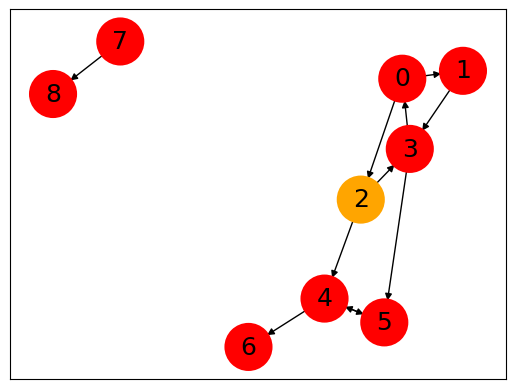

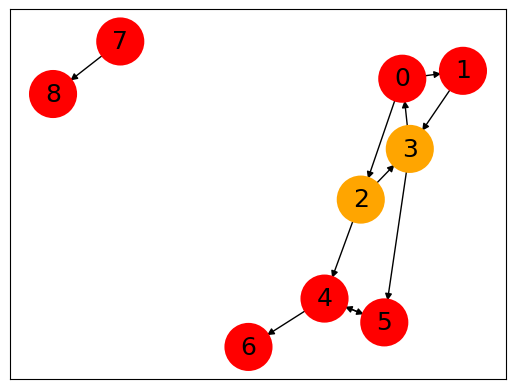

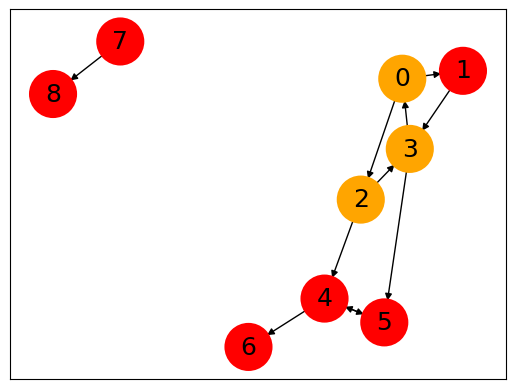

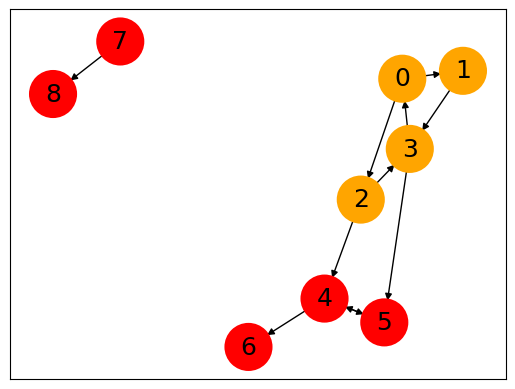

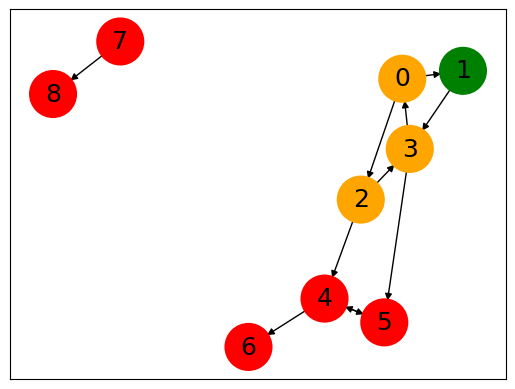

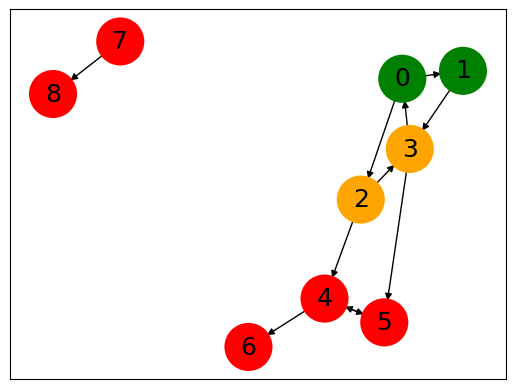

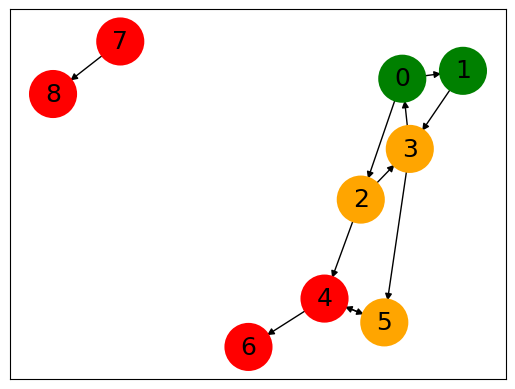

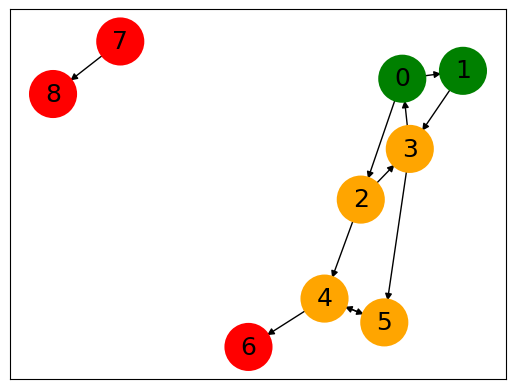

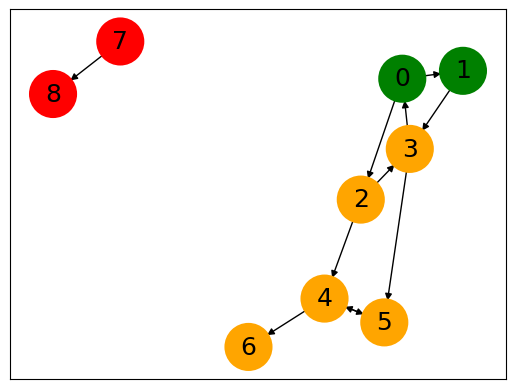

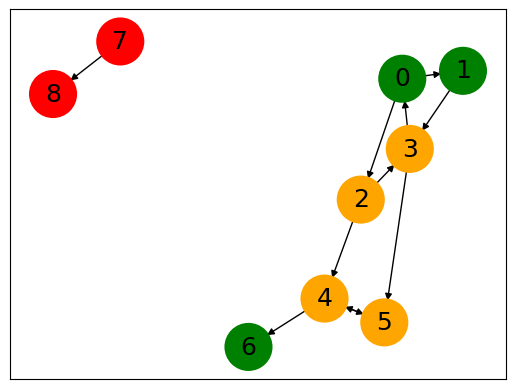

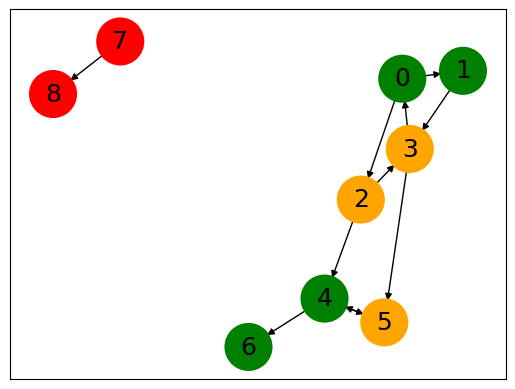

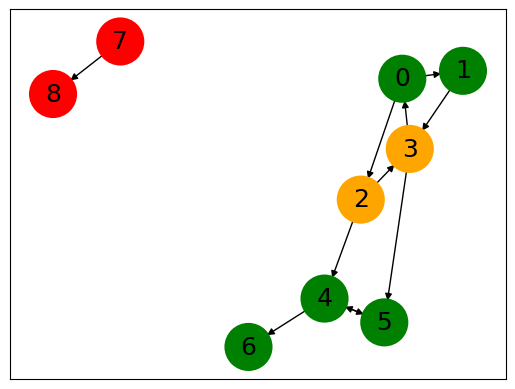

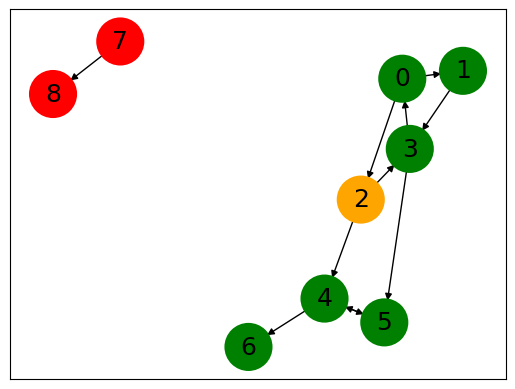

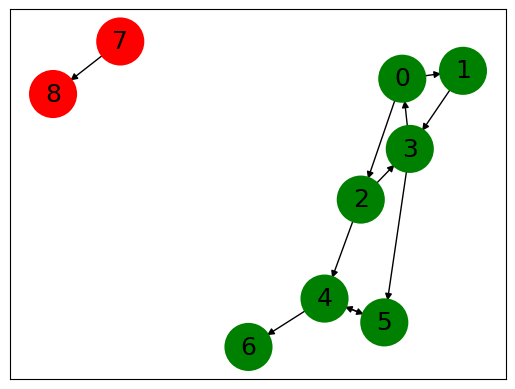

In [231]:
graph.DFS(2)

### Задача 1 - **BFS**

Реализуйте обход в ширину (BFS). Визуализируйте все шаги с помощью networkx.

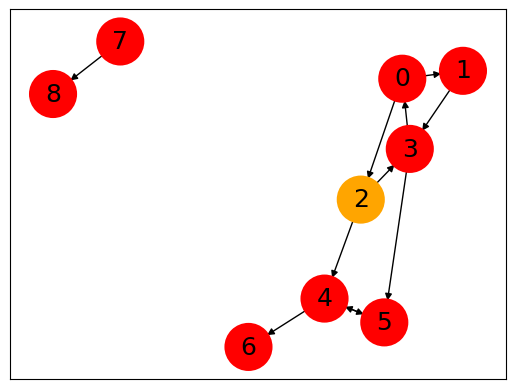

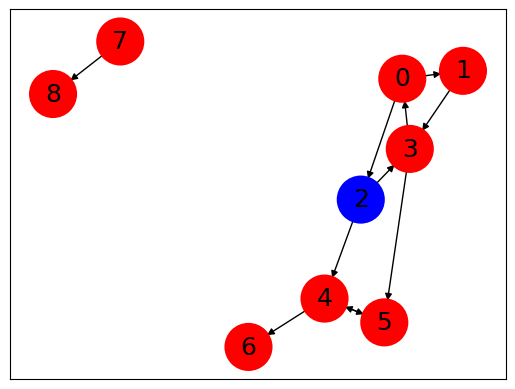

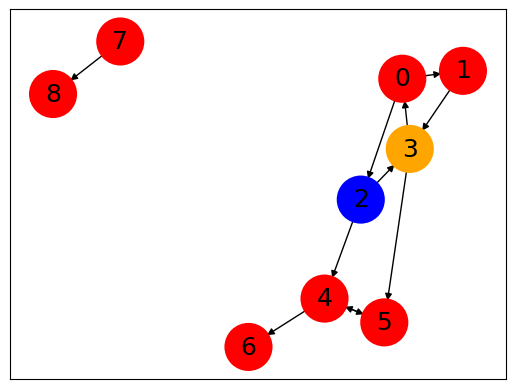

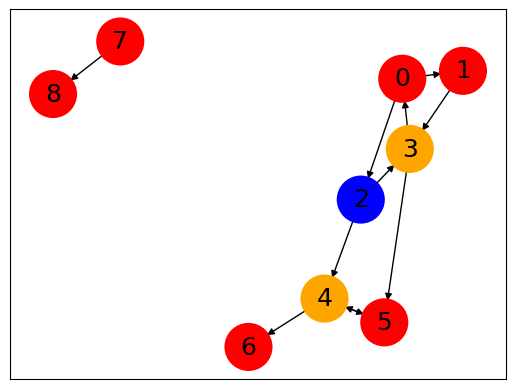

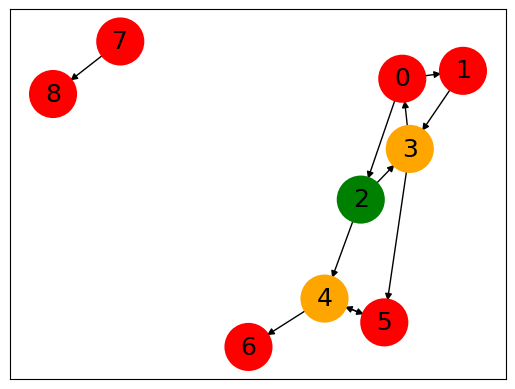

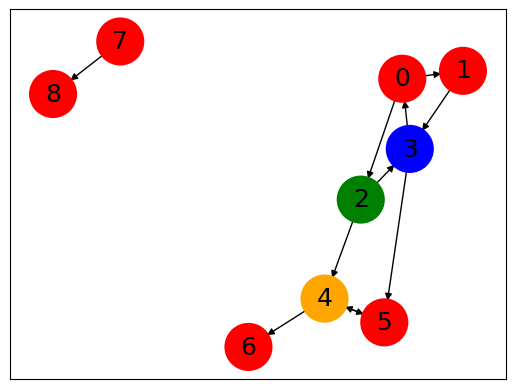

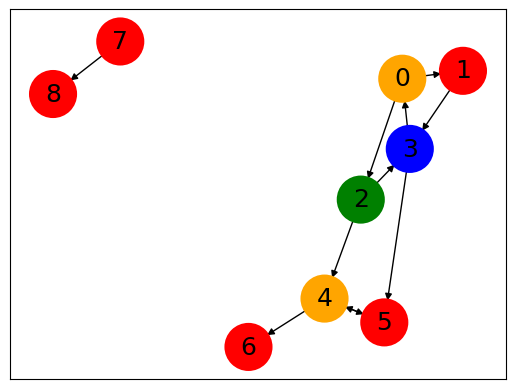

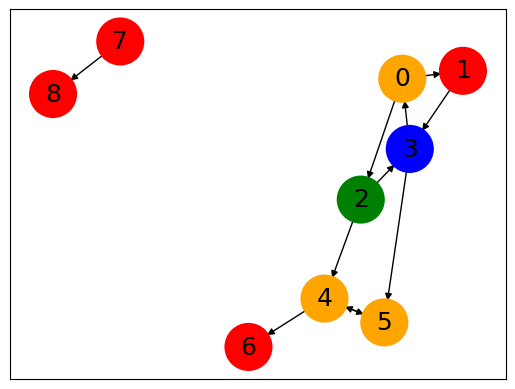

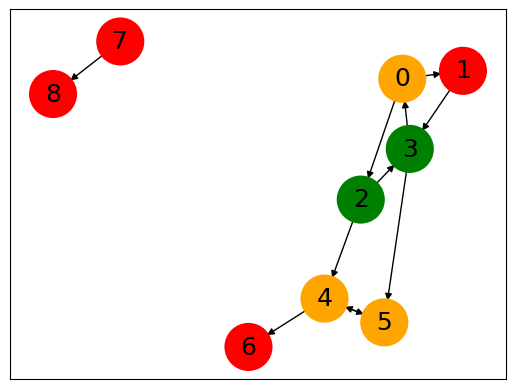

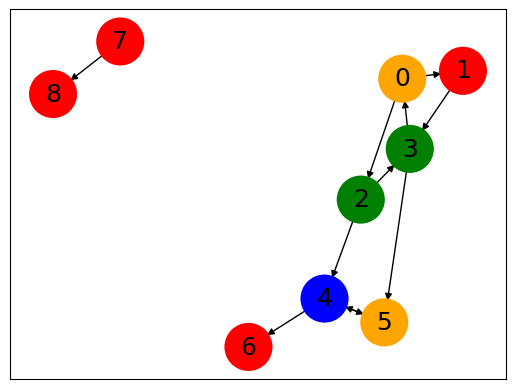

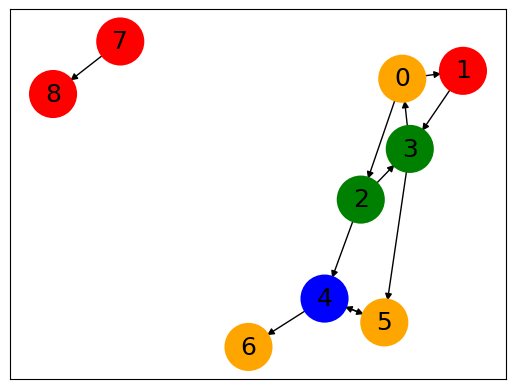

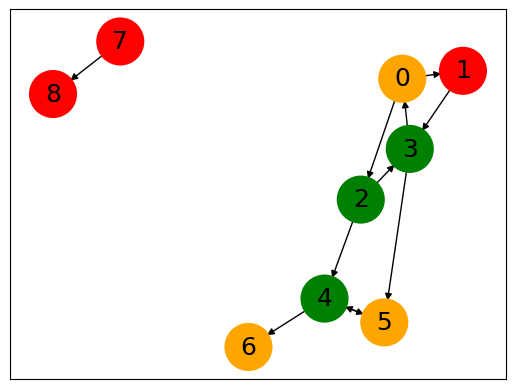

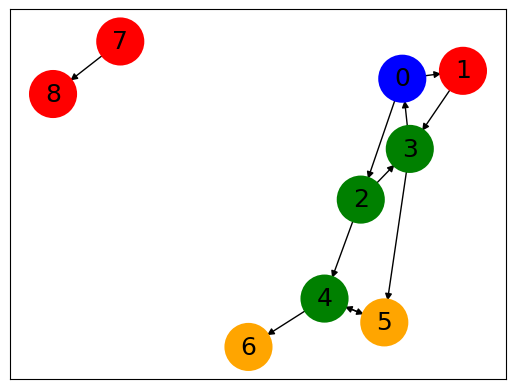

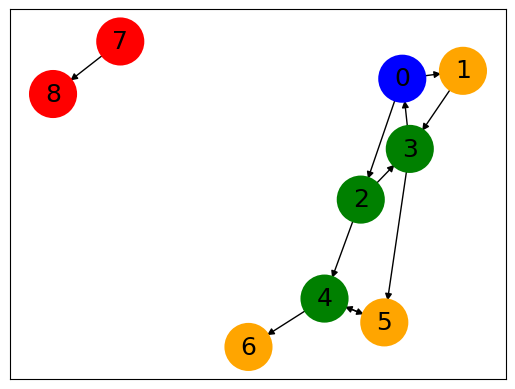

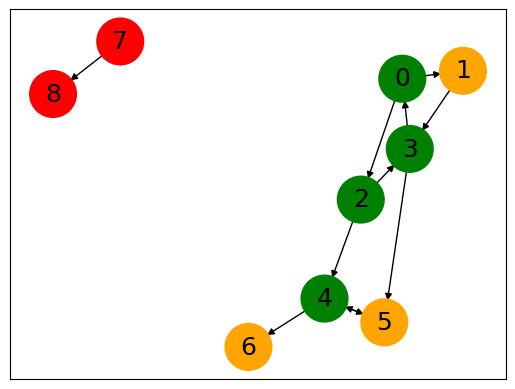

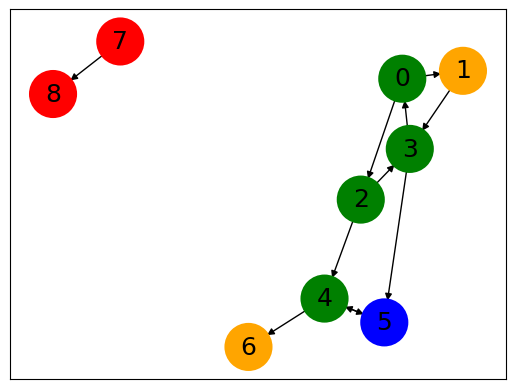

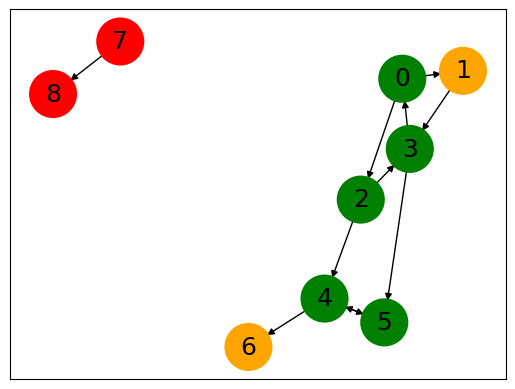

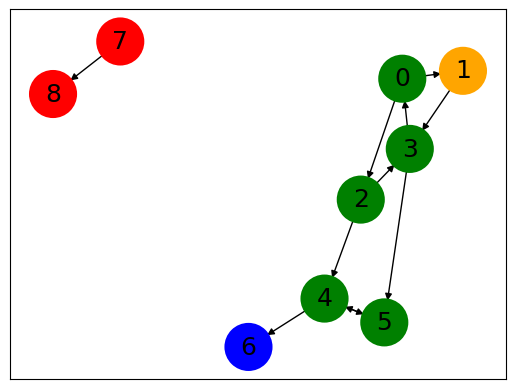

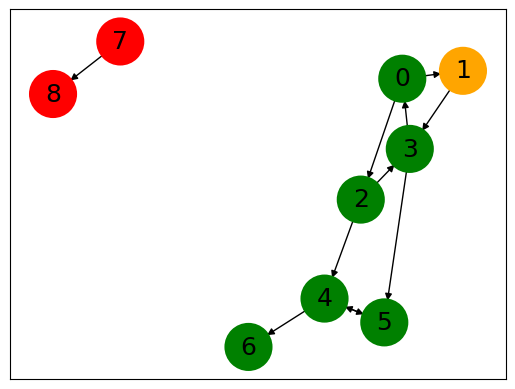

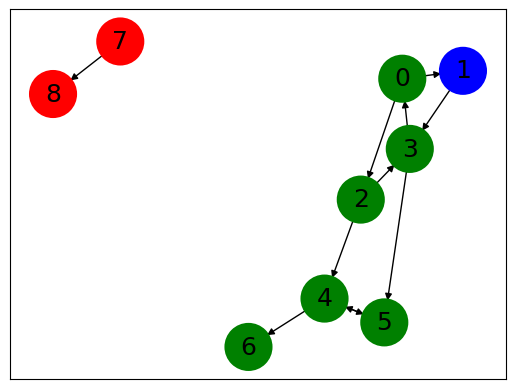

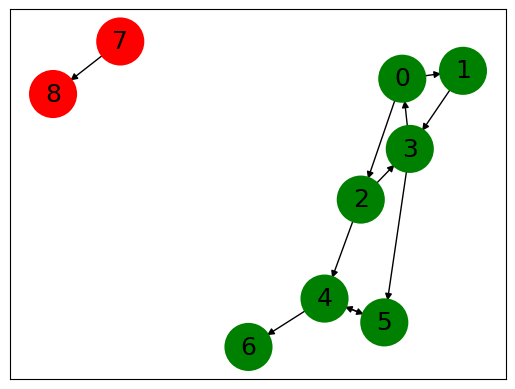

In [232]:
graph.BFS(2)

### Задача 2 - **TopoSort**

Реализуйте топологическую сортировку. Визуализируйте все шаги с помощью networkx.

In [ ]:
# в задании не уточняется что хотим получить от алгоритма. поэтому он просто выводит порядок вершин

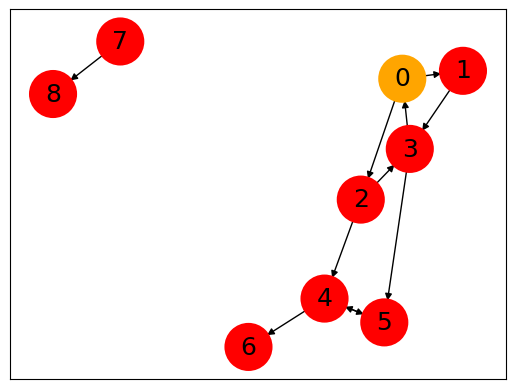

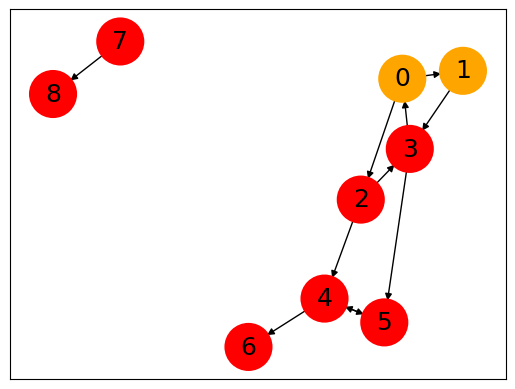

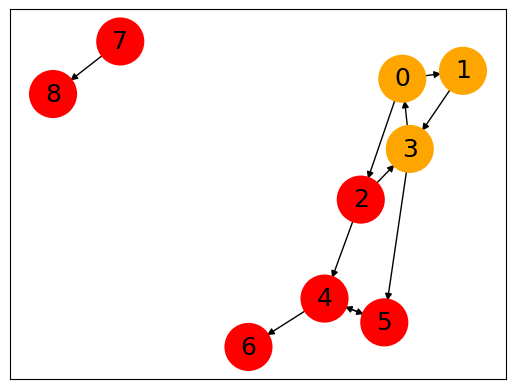

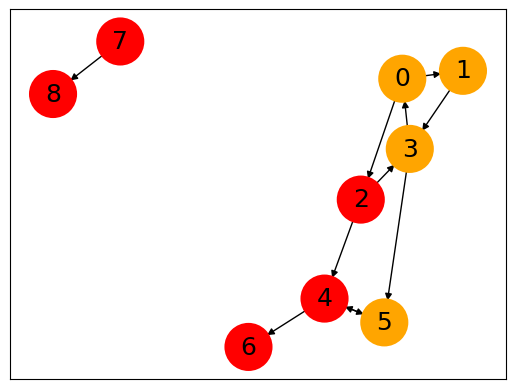

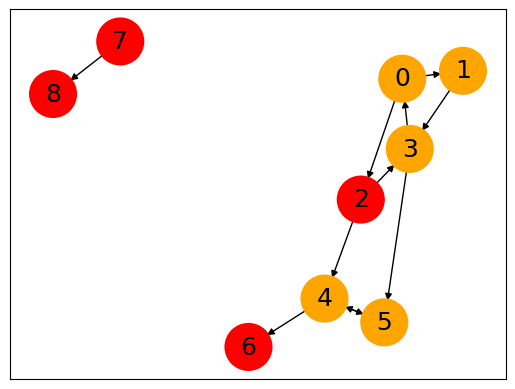

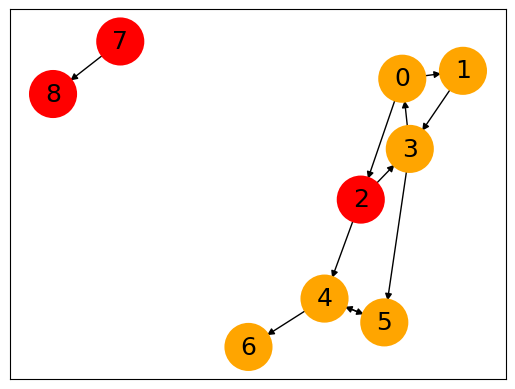

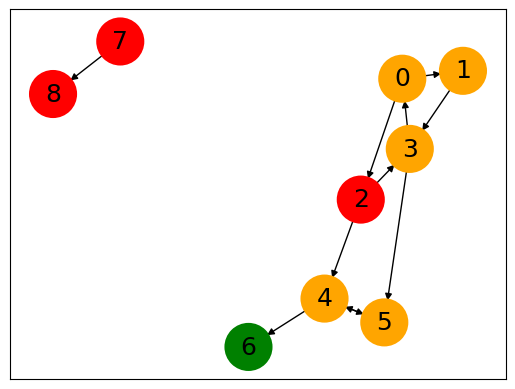

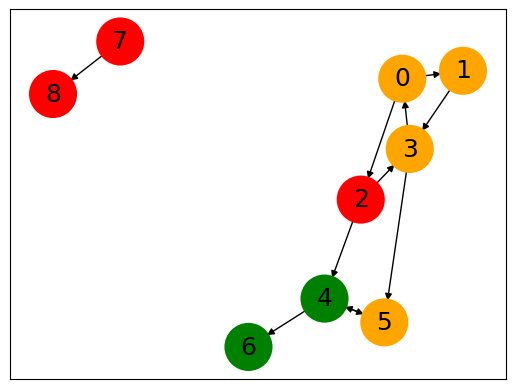

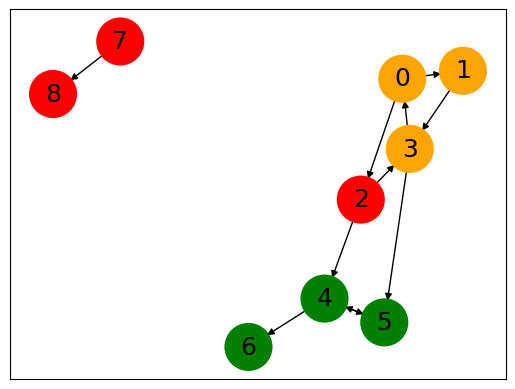

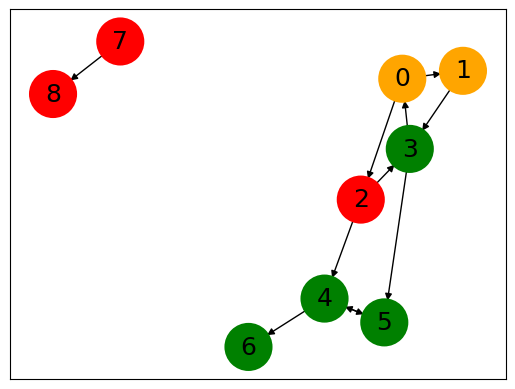

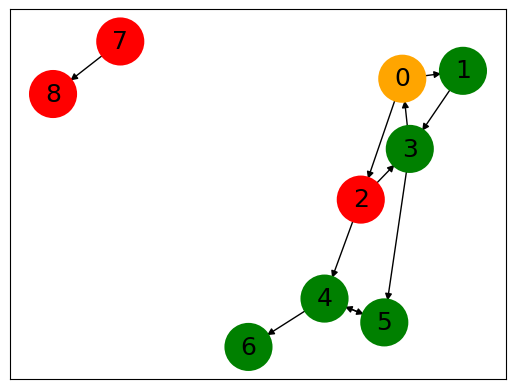

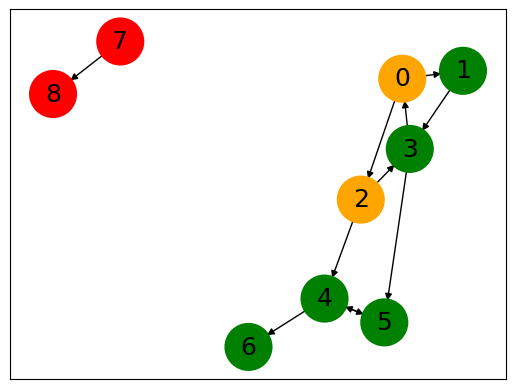

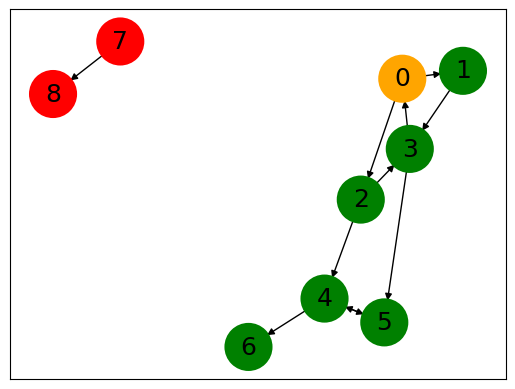

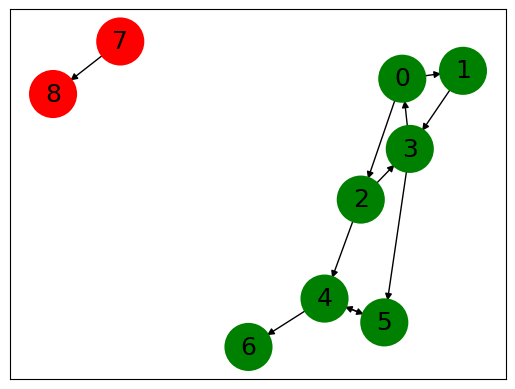

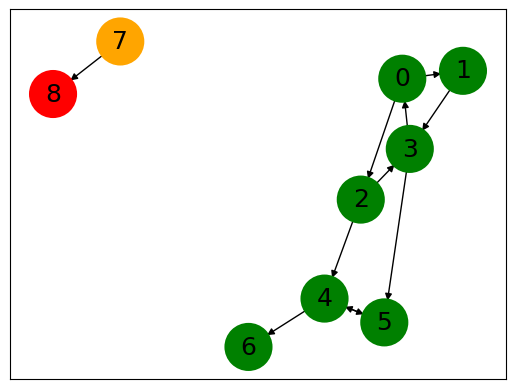

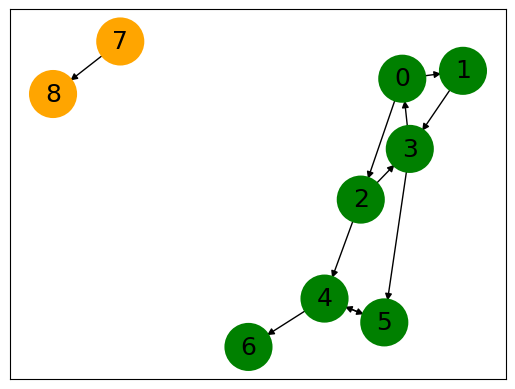

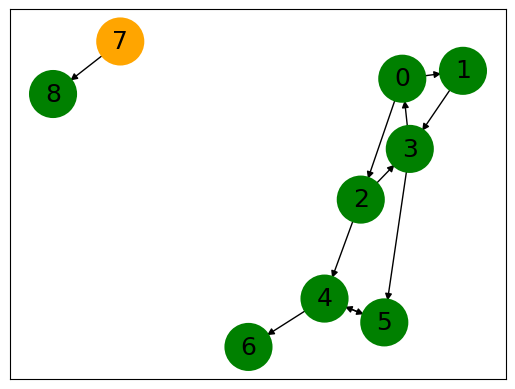

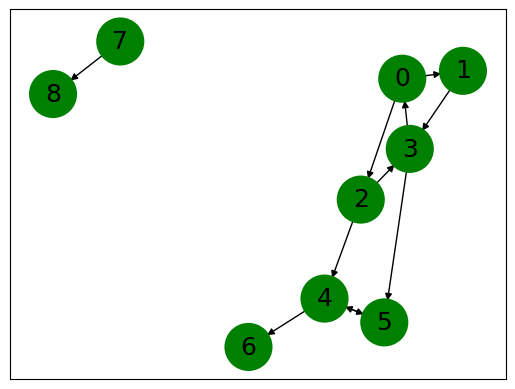

[7, 8, 0, 2, 1, 3, 5, 4, 6]

In [233]:
graph.Toposort()

### Задача 3 - **Strongly Connected Components**

Реализуйте поиск сильно связных компонент и построение метаграфа. Визуализируйте все шаги с помощью networkx.

In [ ]:
# в задании не уточняется что хотим получить от алгоритма. поэтому он просто выводит количество scc

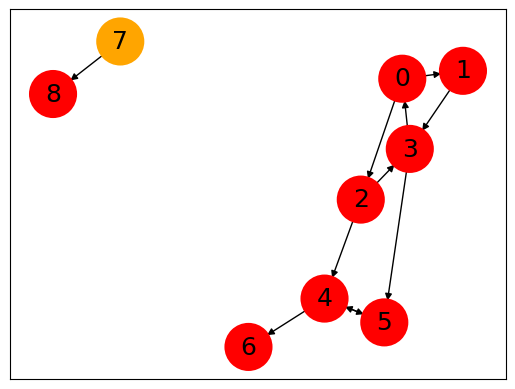

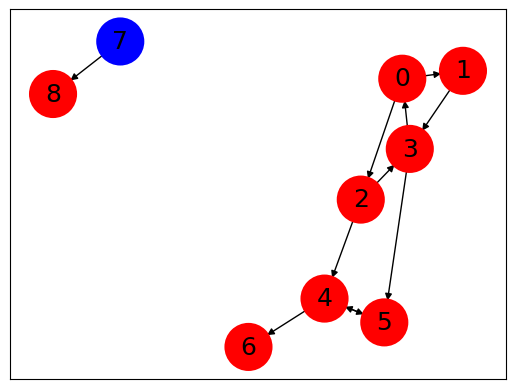

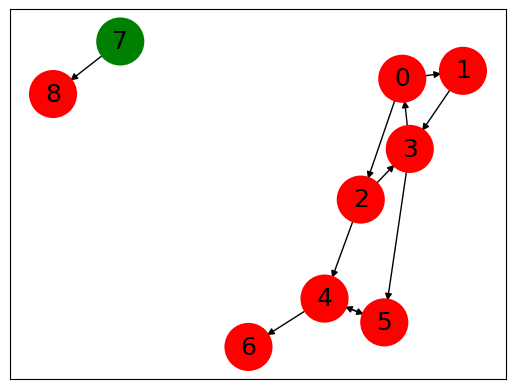

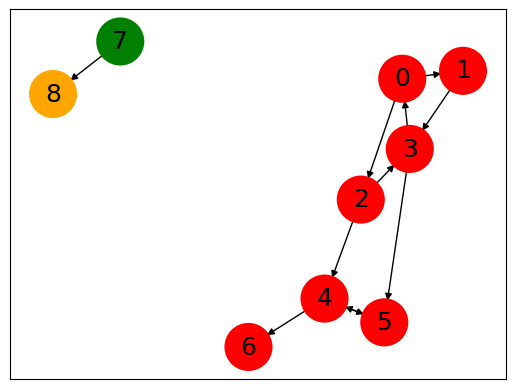

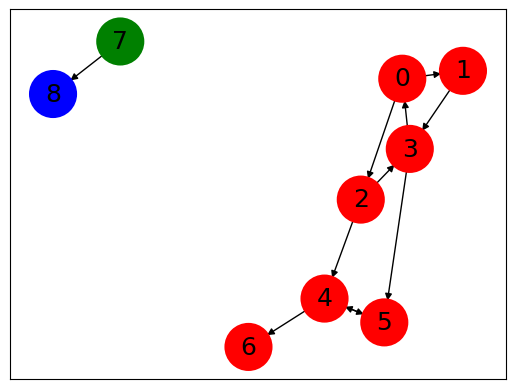

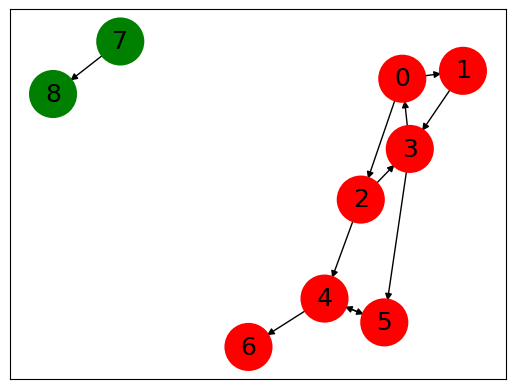

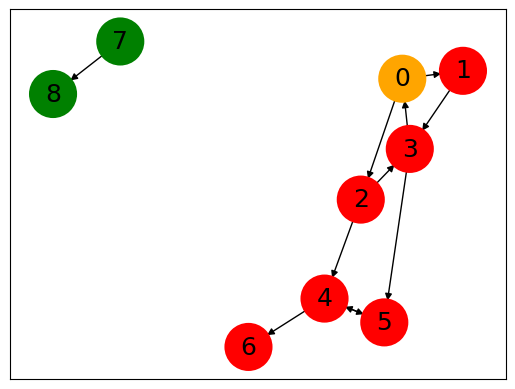

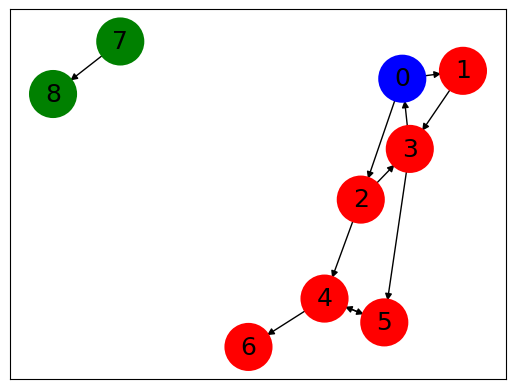

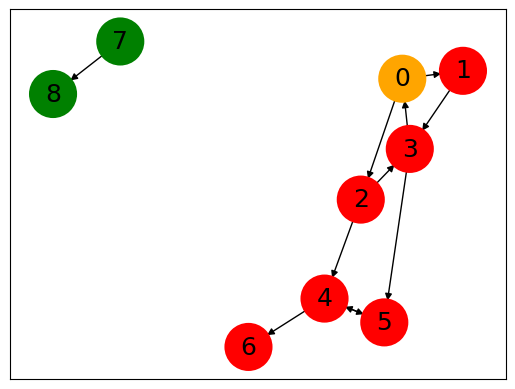

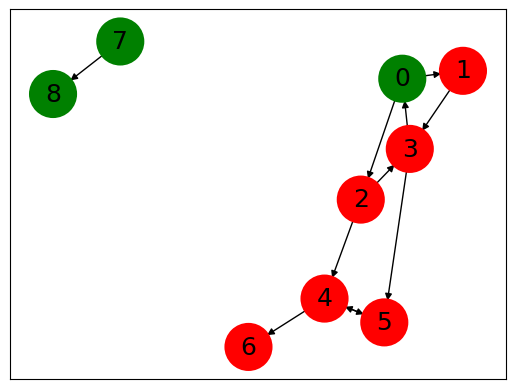

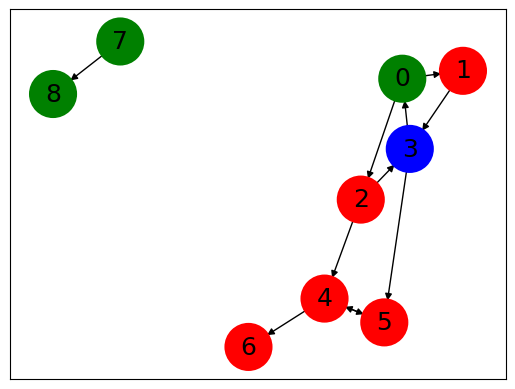

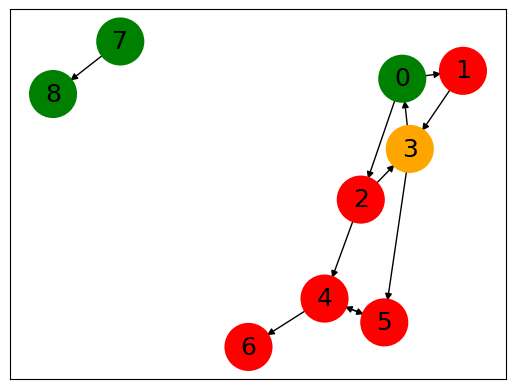

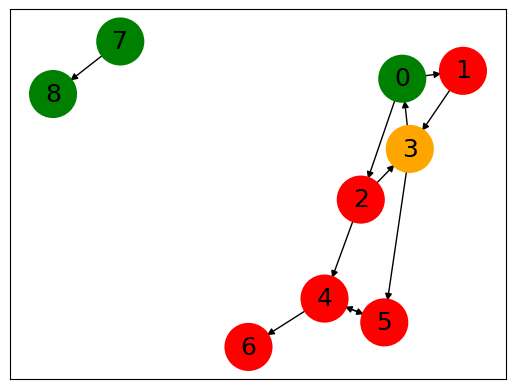

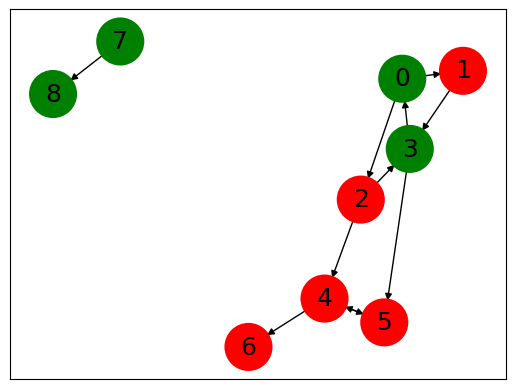

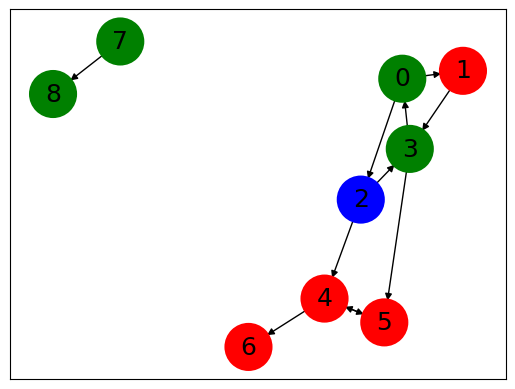

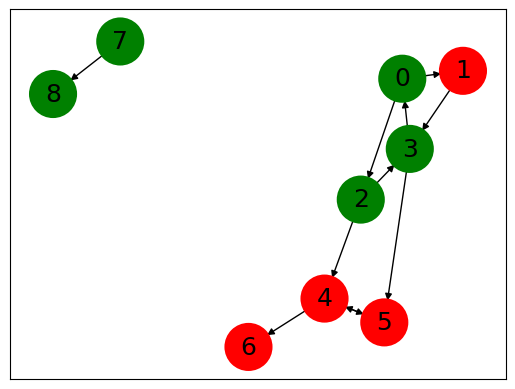

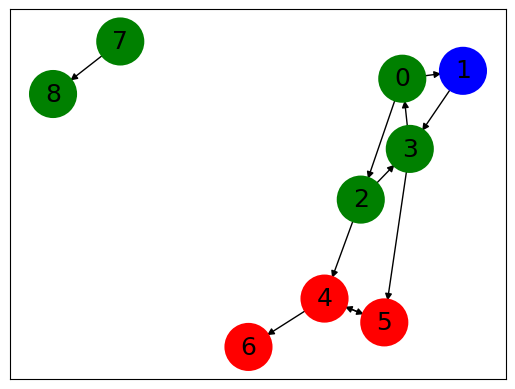

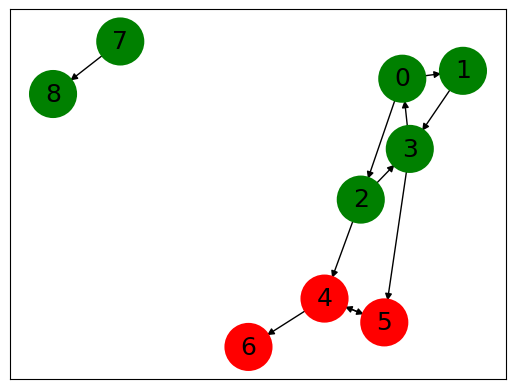

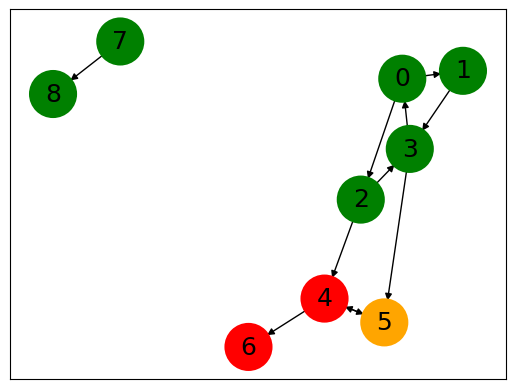

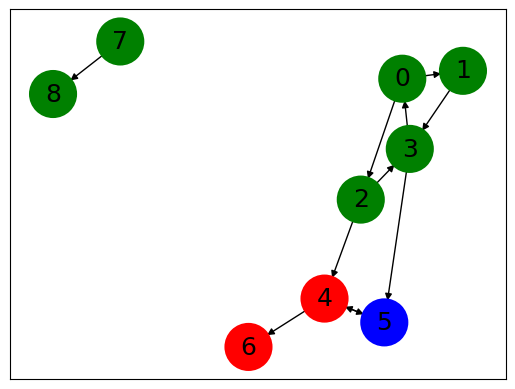

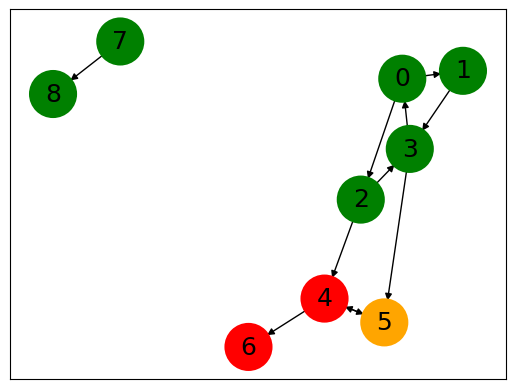

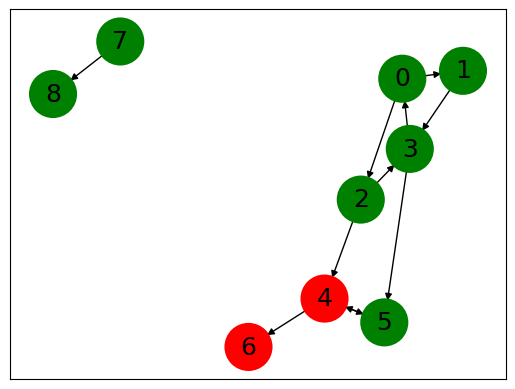

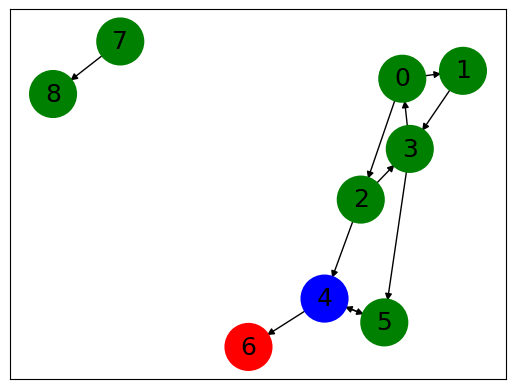

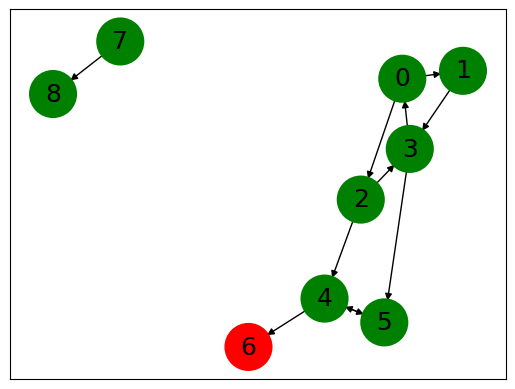

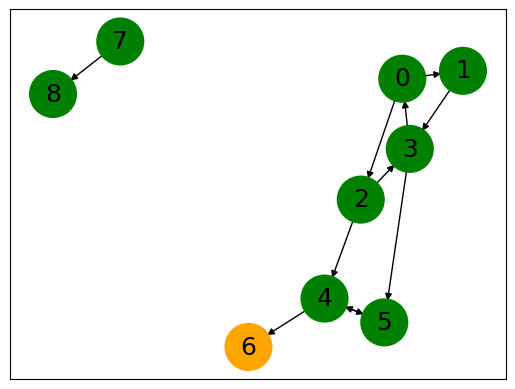

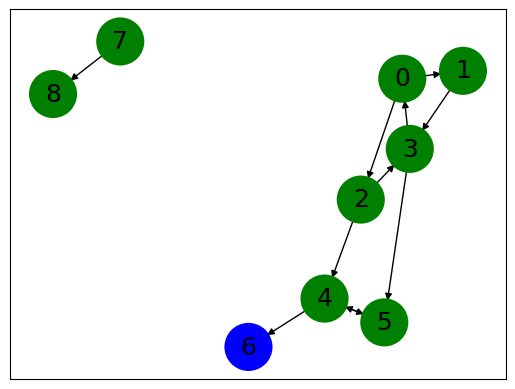

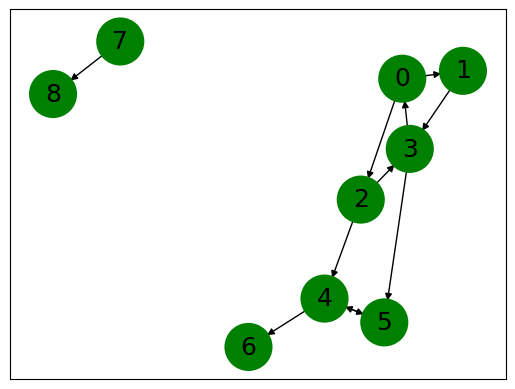

5

In [234]:
graph.StronglyConComp()

### Задача 4

Реализуйте алгоритм, находящий кратчайшее решение Ivy Cube.

In [ ]:
# надо посмотреть, занятие 7 2:12:20

In [2]:

class Ivy_cube:
    def __init__(self):
        self.corner_operations = {"a" : ["y", "b", "o"],
                                  "b" : ["y", "g", "r"],
                                  "c" : ["g", "o", "w"],
                                  "d" : ["r", "w", "b"]}

        self.set_state()

    def set_state(self, state = "0000wygrbo"):
        self.corners = {}

        for i, k in enumerate(self.corner_operations.keys()):
            self.corners[k] = int(state[i])

        self.edges = {"w" : state[4],
                      "y" : state[5],
                      "g" : state[6],
                      "r" : state[7],
                      "b" : state[8],
                      "o" : state[9]}

    def turn(self, corner):

        if corner.islower():
            self.corners[corner] = (self.corners[corner] + 1) % 3
            a1, a2, a3 = self.corner_operations[corner]
            self.edges[a1], self.edges[a2], self.edges[a3] = self.edges[a3], self.edges[a1], self.edges[a2]

        else:
            corner = corner.lower()
            self.corners[corner] = (self.corners[corner] - 1) % 3
            a1, a2, a3 = self.corner_operations[corner]
            self.edges[a1], self.edges[a2], self.edges[a3] = self.edges[a2], self.edges[a3], self.edges[a1]


    def get_state_string(self):
        s =  ""

        for v in self.corners.values():
            s += str(v)

        for v in self.edges.values():
            s += v

        return s

    def __str__(self):
        strtoprint = self.get_state_string()

        return strtoprint

states = set()

cube = Ivy_cube()

print(cube)
cube.turn("b")
print(cube)
cube.turn("b")
print(cube)
cube.turn("b")
print(cube)


states.add(cube.get_state_string())
diameter = 0

while(True):
    new_states = set()

    for state in states:
        for operation in "abcdABCD":
            cube.set_state(state)
            cube.turn(operation)

            new_state = cube.get_state_string()

            if (new_state not in states):
                new_states.add(new_state)

    if (len(new_states) == 0):
        break

    states = states.union(new_states)
    diameter += 1

    print(f"{len(new_states)} states added, now {len(states)}")

print(f"diameter is {diameter}")



0000wygrbo
0100wrygbo
0200wgrybo
0000wygrbo
8 states added, now 9
48 states added, now 57
288 states added, now 345
1640 states added, now 1985
7582 states added, now 9567
15262 states added, now 24829
4221 states added, now 29050
110 states added, now 29160
diameter is 8


In [16]:
len(states)

29160

In [6]:
from collections import deque

def find_shortest_path(state_to_solve):

    # нам надо собрать от state_to_solve до 0000wygrbo

    final_state = "0000wygrbo"
    queue = deque([state_to_solve])
    visited = {state_to_solve}
    paths = {}  # крч тут видимо лучше хранить parent + turn


    # обычный bfs
    while queue:
        state = queue.popleft()

        if state == final_state:
            break

        for operation in "abcdABCD":
            cube.set_state(state)
            cube.turn(operation)

            new_state = cube.get_state_string()

            if new_state not in visited:
                visited.add(new_state)
                queue.append(new_state)
                paths[new_state] = [state, operation]

    turns = []
    current = final_state

    while current != state_to_solve:
        current, turn = paths[current]
        turns.append(turn)

    turns.reverse()
    return turns


cube = Ivy_cube()
state_to_solve = "0100wrygbo"       # знаем что это состояние достигается через 'b' поворот
cube.set_state(state_to_solve)
print(find_shortest_path(state_to_solve))   # значит наоборот должно быть 'B'

['B']


In [7]:

state_to_solve = "1002rwbyog"
path = find_shortest_path(state_to_solve)
print(path)

#let's check

cube = Ivy_cube()
cube.set_state(state_to_solve)

for p in path:
    cube.turn(p)

presumably_solved_state = cube.get_state_string()

print(f"state {presumably_solved_state} reached, solving success {presumably_solved_state == "0000wygrbo"}")

['C', 'A', 'd', 'b', 'c', 'B']
state 0000wygrbo reached, solving success True


### Задача 5

Решите оставшиеся задачи из контеста (это на две недели, т.е. до 26.03)

**✅✅✅ done (lizzzafomenko)**